### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import random
import os

# Reproducibility
seed = 2
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Optional: disable eager execution (if using graph mode code)
tf.compat.v1.disable_eager_execution()

# Session config
session_conf = tf.compat.v1.ConfigProto(
    intra_op_parallelism_threads=1,
    inter_op_parallelism_threads=1
)
sess = tf.compat.v1.Session(config=session_conf)

# Set this session as default for everything that follows
# No set_session needed — use a context manager instead
with sess.as_default():
    # your model/code here
    pass


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pylab import *

import pandas as pd
import pickle
import time
import sys
import json
import os

# import statsmodels
# import statsmodels.api as sm
# from statsmodels.tsa.stattools import coint, adfuller

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Import Datetime and the Pandas DataReader
from datetime import datetime
from pandas_datareader import data, wb

# Import scikit instruments
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, LSTM, GRU, Dropout, TimeDistributed
from keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D 
#from keras.layers.convolutional import Conv1D
#from keras.layers.convolutional import MaxPooling1D
from keras.callbacks import EarlyStopping, ProgbarLogger

### Import Classes

In [3]:
sys.path.append("../classes")
%load_ext autoreload
%aimport class_SeriesAnalyser, class_Trader, class_DataProcessor, class_ForecastingTrader
%autoreload 1

In [4]:
series_analyser = class_SeriesAnalyser.SeriesAnalyser()
trader = class_Trader.Trader()
data_processor = class_DataProcessor.DataProcessor()
forecasting_trader = class_ForecastingTrader.ForecastingTrader()

Function to evaluate forecasting results:

In [5]:
def evaluate_forecasting(n_pairs, true_values, prediction_values):
    mse, mae, rmse, accuracy, bias = list(), list(), list(), list(), list()
    std_dev = list()
    for i in range(n_pairs):
        mse.append(mean_squared_error(true_values[i], prediction_values[i]))
        rmse.append(np.sqrt(mean_squared_error(true_values[i], prediction_values[i])))
        mae.append(mean_absolute_error(true_values[i], prediction_values[i]))
        accuracy.append(forecasting_trader.calculate_direction_accuracy(true_values[i], prediction_values[i]))
        bias.append((true_values[i] - prediction_values[i]).mean())
        std_dev.append(prediction_values[i].std())
    print('{:.2f}E-4'.format(np.mean(mse)*10000))#Average MSE: 
    print('{:.2f}E-3'.format(np.mean(rmse)*1000))#Average RMSE: 
    print('{:.2f}E-3'.format(np.mean(mae)*1000))#Average RMSE: 
    print('{:.2f}%'.format(np.mean(accuracy)))#Average Directional Accuracy: 
    #print('Bias: {:.2f}E-4'.format(np.mean(bias)*10000))
    #print('Average Standard Deviation from prediction signal ', np.mean(std_dev))
    
    return mse, mae, rmse, accuracy

### MLP

In [6]:
def plot_loss(history, title, epoch_stop, metric='mse'):
    """
    Function to plot loss function.
    Arguments:
    history: History object with data from training.
    title: Plot title.
    """
    plt.figure(figsize=(7,5))
    #plt.grid()
    if metric == 'mse':
        plt.plot(history['loss'], label = "Training MSE")
        plt.plot(history['val_loss'], label = "Validation MSE")
        plt.plot([epoch_stop], [history['val_loss'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MSE:{:.3f}'.format(history['val_loss'][epoch_stop]),
            xy=(epoch_stop, history['val_loss'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Squared Error', size=12)
    elif metric == 'mae':
        plt.plot(history['mean_absolute_error'], label = "Training MAE")
        plt.plot(history['val_mean_absolute_error'], label = "Validation MAE")
        plt.plot([epoch_stop], [history['val_mean_absolute_error'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MAE:{:.3f}'.format(history['val_mean_absolute_error'][epoch_stop]),
            xy=(epoch_stop, history['val_mean_absolute_error'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Absolute Error', size=12)
    plt.xlabel('Epochs', size=12)
    plt.legend()
    plt.savefig('{}_history.png'.format(metric), bbox='tight')
    
def plot_predictions(summaries):
    
    n_pairs = len(summaries)
    fig, ax = plt.subplots(n_pairs, 1, figsize=(20,25))
    
    for i in range(n_pairs):
        #title('Pair: {}'.format(i))
        predictions = summaries[i]['prediction(t)']
        spread = summaries[i]['spread(t)']
        ax[i].plot(predictions, 'b')
        ax[i].plot(spread, 'r')
    return None

In [7]:
def read_models(path='models/'):
    all_models = [] # Creates an empty list
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".pkl"):
                with open(path+file, 'rb') as f:
                    models = pickle.load(f)
                all_models.append(models)
                
    return all_models

In [8]:
with open(f'PCA_selected_pairs.pickle', 'rb') as handle: 
    pairs = pickle.load(handle)
len(pairs)

15

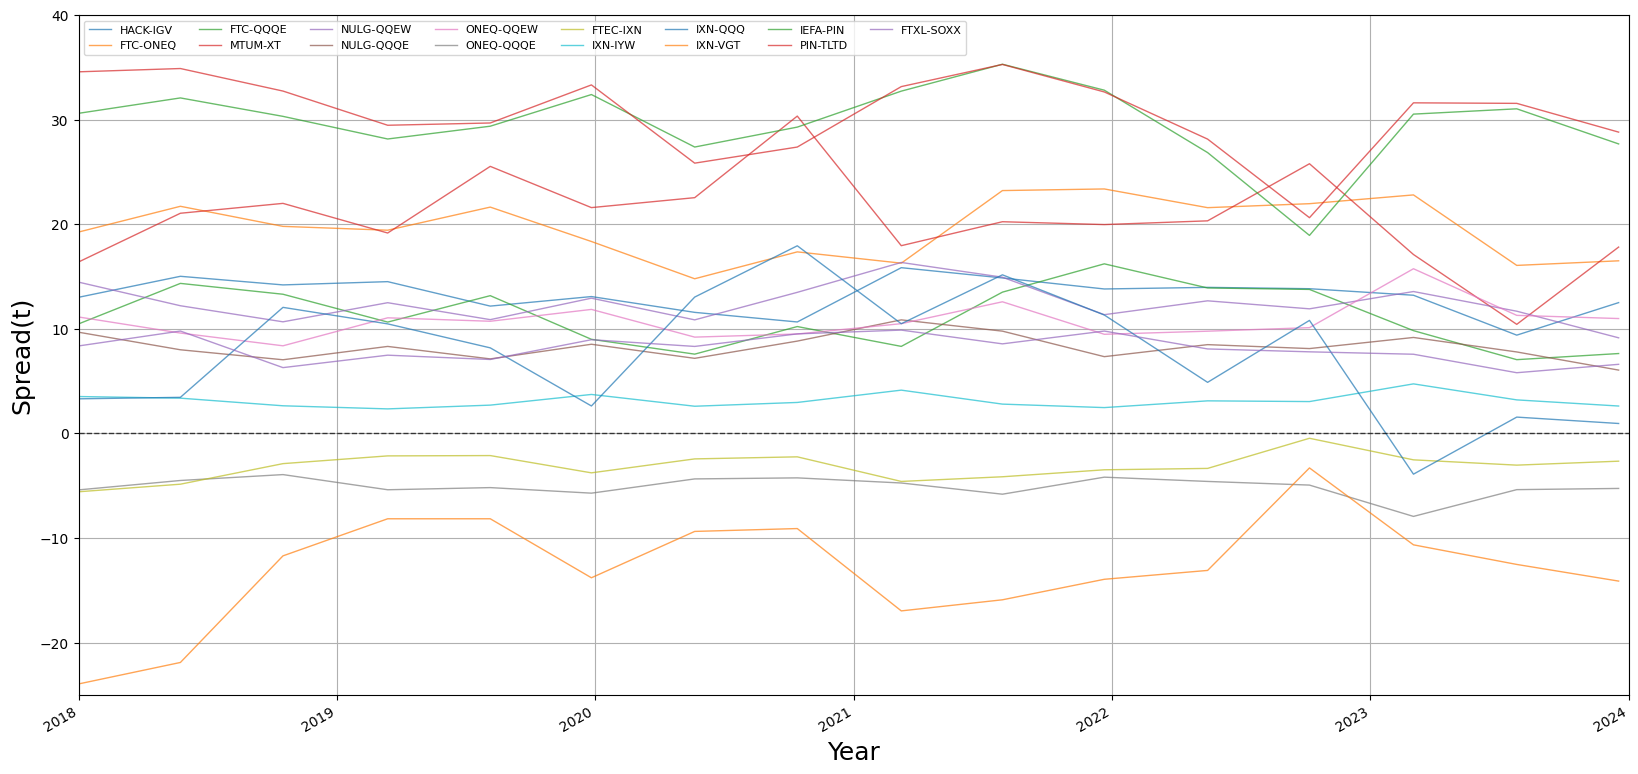

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(
        ax=ax,
        grid=True,
        label='{}-{}'.format(pairs[i][0], pairs[i][1]),
        linewidth=1,
        alpha=0.7
    )
ax.set_ylabel('Spread(t)', size=18)
ax.set_xlabel('Year', size=18)
ax.set_xlim(('2018', '2024'))
ax.legend(fontsize=8, loc='upper left', ncol=8)
#ax.set_title(f'Spreads of the {len(pairs)} Selected Pairs', size=16)
#ax.set_yscale('symlog', linthresh=1)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_ylim(-25, 40)
plt.savefig('images/CAE_spreads.png', bbox_inches='tight', pad_inches=0.05)

## Validation Set

In [11]:
rnn_models = read_models(path=f'models/mlp/') 
rnn_models

[[{'leg1': 'HACK',
   'leg2': 'IGV',
   'standardization_dict': 'scaler',
   'history': {'loss': [0.31995975971221924,
     0.22610102593898773,
     0.1885303258895874,
     0.16560611128807068,
     0.14856883883476257,
     0.13755330443382263,
     0.1271740049123764,
     0.11909150332212448,
     0.11124756932258606,
     0.10437244921922684,
     0.09829718619585037,
     0.09300455451011658,
     0.08833639323711395,
     0.08426700532436371,
     0.08061858266592026,
     0.07724680006504059,
     0.07427845895290375,
     0.07129248976707458,
     0.06871320307254791,
     0.0662953332066536,
     0.06417050957679749,
     0.0622076690196991,
     0.06043996289372444,
     0.058745045214891434,
     0.057122111320495605,
     0.055684566497802734,
     0.05420922115445137,
     0.053012553602457047,
     0.05171974003314972,
     0.05079906806349754,
     0.049605656415224075,
     0.048929791897535324,
     0.04784899950027466,
     0.047372303903102875,
     0.0462700091302

In [12]:
etf_list = pd.read_excel(f'tech_etfs.xlsx')
ticker_segment_dict = dict(zip(etf_list['Ticker'], etf_list['Description']))
ticker_segment_dict

{'ARKK': 'ARK Innovation ETF',
 'ARKQ': 'ARK Autonomous Technology & Robotics ETF',
 'ARKW': 'ARK Next Generation Internet ETF',
 'CIBR': 'First Trust NASDAQ Cybersecurity ETF',
 'CQQQ': 'Invesco China Technology ETF',
 'CWEB': 'Direxion Daily CSI China Internet Bull 2X Shares',
 'DTEC': 'ALPS Disruptive Technologies ETF',
 'FDN': 'First Trust Dow Jones Internet Index Fund',
 'FTC': 'First Trust Large Cap Growth AlphaDEX Fund',
 'FTEC': 'Fidelity MSCI Information Technology Index ETF',
 'FTXL': 'First Trust Nasdaq Semiconductor ETF',
 'FXI': 'iShares China Large-Cap ETF',
 'FXL': 'First Trust Technology AlphaDEX Fund',
 'FXP': 'ProShares UltraShort FTSE China 50',
 'FYC': 'First Trust Small Cap Growth AlphaDEX Fund',
 'GAMR': 'Wedbush ETFMG Video Game Tech ETF',
 'HACK': 'ETFMG Prime Cyber Security ETF',
 'IDLV': 'Invesco S&P International Developed Low Volatility ETF',
 'IDMO': 'Invesco S&P International Developed Momentum ETF',
 'IDX': 'VanEck Vectors Indonesia Index ETF',
 'IEFA': '

In [13]:
# model to test
n_in = 24
hidden_nodes = [[50]]
low_quantile = 0.10
high_quantile = 0.90
train_val_split = '01-01-2023'

mlp_path=(f'models/mlp/')

In [15]:
model_rnn, cumret_val, sharperatio_val,summaries_rnn, balance_summaries_rnn = \
            forecasting_trader.run_specific_model(
                                                n_in, 
                                                hidden_nodes, 
                                                pairs,
                                                path=mlp_path,
                                                train_val_split=train_val_split,
                                                low_quantile=low_quantile, 
                                                high_quantile=high_quantile, 
                                                lag=1,
                                                )

In [16]:
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
#performance_rnn

Annual ROI:  -8.182780866939677
13.333333333333334 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -6.372994738811304
Autocorrelation:  0.013916750688118904
Daily Sharpe Ratio -0.4087887376518433
Total number of trades:  217
Positive trades:  86
Negative trades:  131
Total Drawdown Days: 157 days
Max DD period: 3 days
Maximum drawdown of portfolio: -8.35%


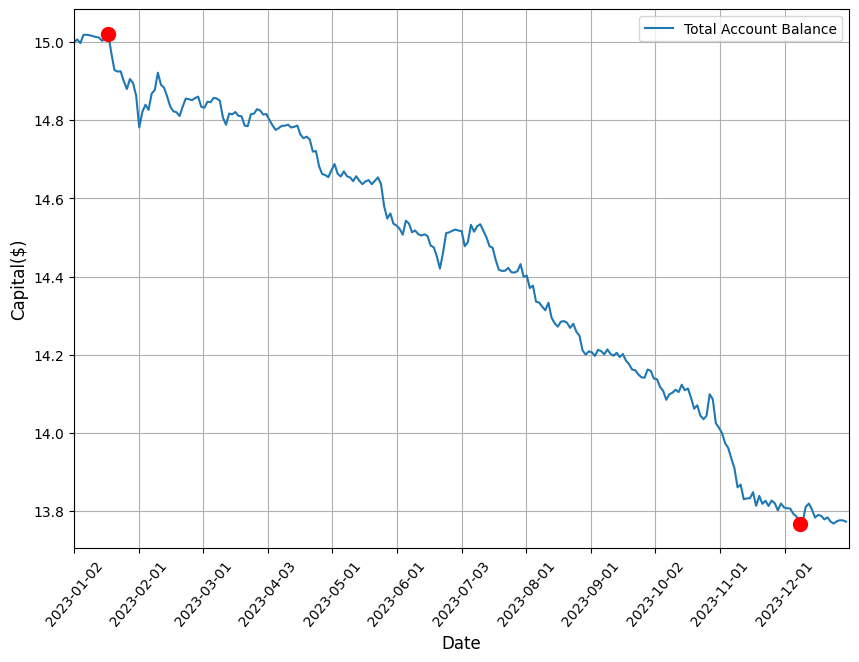

In [17]:
results, pairs_summary = trader.summarize_results(sharperatio_val,
                                                  cumret_val,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [18]:
results

{'n_pairs': 15,
 'portfolio_sharpe_ratio': -0.4087887376518433,
 'avg_total_roi': -8.182780866939677,
 'avg_annual_roi': -8.182780866939677,
 'pct_positive_trades_per_pair': 41.89417609680767,
 'pct_pairs_with_positive_results': 13.333333333333334,
 'avg_half_life': 50.666666666666664,
 'avg_hurst_exponent': 0.42059157881012094}

Training:

In [19]:
init = model_rnn[0]['predictions_train'].index[0]
true_train = [pairs[i][2]['spread'][init:train_val_split] for i in range(len(pairs))]
predictions_train = [model_rnn[i]['predictions_train'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_train, predictions_train)

3888.77E-4
553.11E-3
417.88E-3
49.18%


Validation:

In [20]:
true_val = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_val, predictions)

5468.60E-4
638.97E-3
494.64E-3
49.21%


## **Test unrestricted**

In [22]:
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(
                n_in, 
                hidden_nodes, 
                pairs, 
                path=mlp_path,
                low_quantile=low_quantile, 
                high_quantile=high_quantile, 
                lag=1, 
                profitable_pairs_indices=range(len(pairs))
                )
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
#performance_rnn 

Annual ROI:  -7.536766605517742
26.666666666666668 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -4.5864207817429365
Autocorrelation:  0.001143220738514079
Daily Sharpe Ratio -0.29159500381782527
Total number of trades:  217
Positive trades:  86
Negative trades:  131
Total Drawdown Days: 133 days
Max DD period: 3 days
Maximum drawdown of portfolio: -7.84%


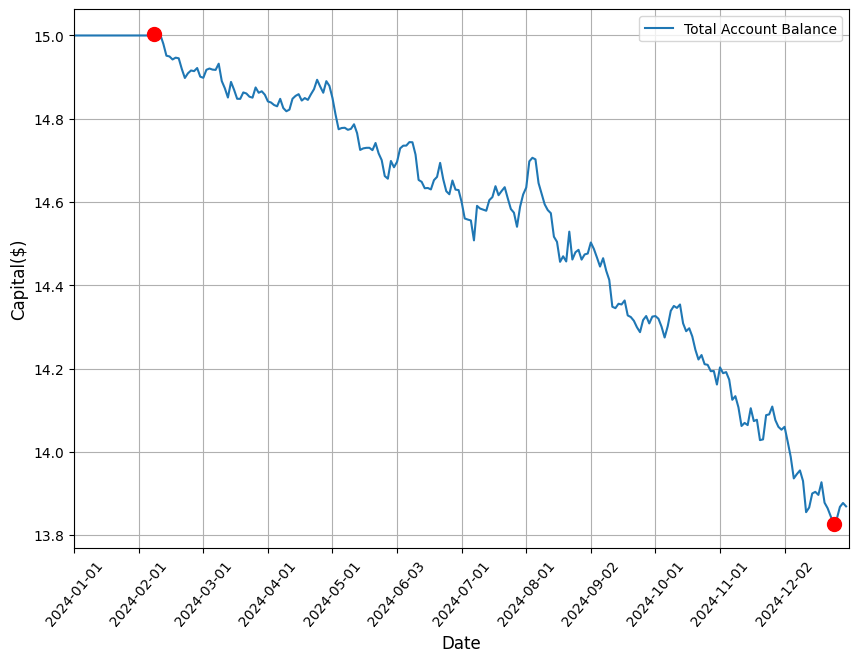

In [23]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [24]:
results

{'n_pairs': 15,
 'portfolio_sharpe_ratio': -0.29159500381782527,
 'avg_total_roi': -7.536766605517746,
 'avg_annual_roi': -7.536766605517742,
 'pct_positive_trades_per_pair': 37.84049954339809,
 'pct_pairs_with_positive_results': 26.666666666666668,
 'avg_half_life': 50.666666666666664,
 'avg_hurst_exponent': 0.42059157881012105}

In [25]:
pairs_summary 

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.519986,0.007488,60,59,0.397805,4,1,0.443872,80.000000
1,PIN,Invesco India ETF,TLTD,FlexShares Morningstar Developed Markets ex-US...,-2.926240,0.042381,45,85,0.486149,7,7,0.262123,50.000000
2,FTXL,First Trust Nasdaq Semiconductor ETF,SOXX,iShares PHLX Semiconductor ETF,-2.867138,0.049305,97,31,0.367390,4,6,0.160618,40.000000
3,IEFA,iShares Core MSCI EAFE ETF,PIN,Invesco India ETF,-2.703027,0.073516,73,77,0.471957,5,4,-0.158223,55.555556
4,IXN,iShares Global Tech ETF,QQQ,Invesco QQQ Trust,-2.689835,0.075814,48,63,0.421462,16,11,-0.701906,59.259259
5,MTUM,iShares MSCI USA Momentum Factor ETF,XT,iShares Exponential Technologies ETF,-4.375083,0.000328,114,28,0.374344,0,1,-0.714069,0.000000
6,IXN,iShares Global Tech ETF,VGT,Vanguard Information Technology Index Fund ETF...,-3.262747,0.016628,64,50,0.407756,5,10,-1.266575,33.333333
7,FTC,First Trust Large Cap Growth AlphaDEX Fund,ONEQ,Fidelity Nasdaq Composite Index ETF,-2.924680,0.042552,82,60,0.451281,4,7,-1.638478,36.363636
8,ONEQ,Fidelity Nasdaq Composite Index ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.491915,0.008197,102,38,0.437543,4,3,-1.878311,57.142857
9,NULG,Nuveen ESG Large-Cap Growth ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.131589,0.024302,105,38,0.384893,0,1,-1.899854,0.000000


Test:

In [26]:
true_test = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_test, predictions)

30797.91E-4
1384.07E-3
1123.14E-3
48.33%


## **Test with active pairs on validation set**

In [35]:
cumret_val = np.asarray(cumret_val)
profitable_pairs_indices = np.argwhere(cumret_val > 0)
profitable_pairs = [pairs[i] for i in profitable_pairs_indices.flatten()]
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=mlp_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=profitable_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(profitable_pairs))]
#performance_rnn

Annual ROI:  7.7045618173334995
100.0 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  0.2737085537965065
Autocorrelation:  -0.12894896077514711
Daily Sharpe Ratio 0.019381086483413155
Total number of trades:  15
Positive trades:  8
Negative trades:  7
Total Drawdown Days: 98 days
Max DD period: 0 days
Maximum drawdown of portfolio: -5.65%


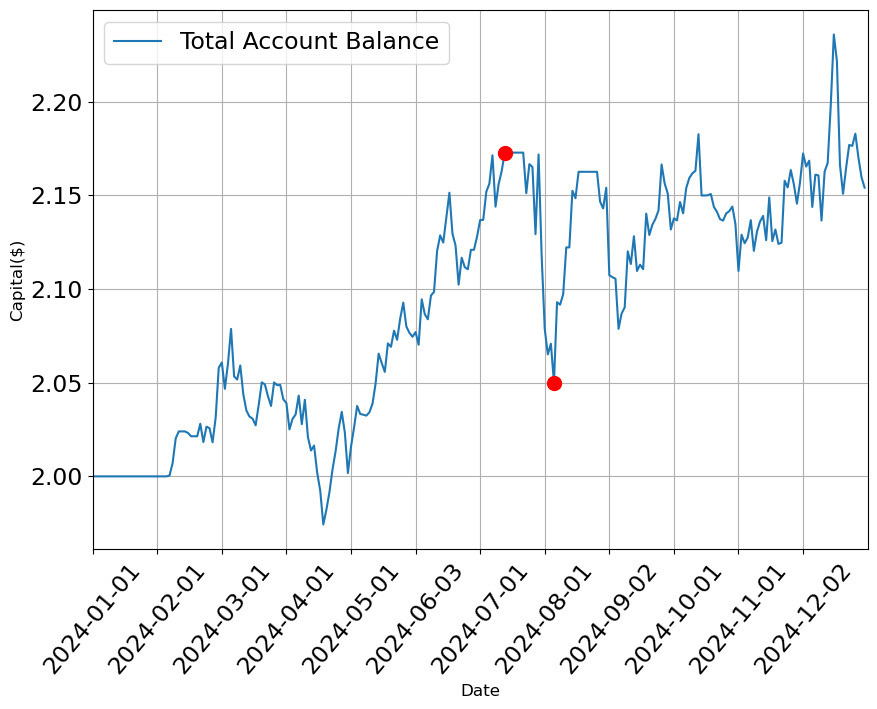

In [27]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  profitable_pairs, ticker_segment_dict,
                                                  n_years=1)                                                

In [29]:
results  

{'n_pairs': 15,
 'portfolio_sharpe_ratio': -0.29159500381782527,
 'avg_total_roi': -7.536766605517746,
 'avg_annual_roi': -7.536766605517742,
 'pct_positive_trades_per_pair': 37.84049954339809,
 'pct_pairs_with_positive_results': 26.666666666666668,
 'avg_half_life': 50.666666666666664,
 'avg_hurst_exponent': 0.42059157881012105}

In [30]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.519986,0.007488,60,59,0.397805,4,1,0.443872,80.000000
1,PIN,Invesco India ETF,TLTD,FlexShares Morningstar Developed Markets ex-US...,-2.926240,0.042381,45,85,0.486149,7,7,0.262123,50.000000
2,FTXL,First Trust Nasdaq Semiconductor ETF,SOXX,iShares PHLX Semiconductor ETF,-2.867138,0.049305,97,31,0.367390,4,6,0.160618,40.000000
3,IEFA,iShares Core MSCI EAFE ETF,PIN,Invesco India ETF,-2.703027,0.073516,73,77,0.471957,5,4,-0.158223,55.555556
4,IXN,iShares Global Tech ETF,QQQ,Invesco QQQ Trust,-2.689835,0.075814,48,63,0.421462,16,11,-0.701906,59.259259
5,MTUM,iShares MSCI USA Momentum Factor ETF,XT,iShares Exponential Technologies ETF,-4.375083,0.000328,114,28,0.374344,0,1,-0.714069,0.000000
6,IXN,iShares Global Tech ETF,VGT,Vanguard Information Technology Index Fund ETF...,-3.262747,0.016628,64,50,0.407756,5,10,-1.266575,33.333333
7,FTC,First Trust Large Cap Growth AlphaDEX Fund,ONEQ,Fidelity Nasdaq Composite Index ETF,-2.924680,0.042552,82,60,0.451281,4,7,-1.638478,36.363636
8,ONEQ,Fidelity Nasdaq Composite Index ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.491915,0.008197,102,38,0.437543,4,3,-1.878311,57.142857
9,NULG,Nuveen ESG Large-Cap Growth ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.131589,0.024302,105,38,0.384893,0,1,-1.899854,0.000000


# Sharpe Ratio active pairs

In [56]:
sharperatio_val = np.asarray(sharperatio_val)
sr_pairs_indices = np.argwhere(sharperatio_val > -1)
sr_pairs = [pairs[i] for i in sr_pairs_indices.flatten()]

model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=mlp_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=sr_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(sr_pairs))]

Annual ROI:  3.369111830432603
66.66666666666667 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -0.1910171835910082
Autocorrelation:  -0.18646901919202674
Daily Sharpe Ratio -0.00888553775611315
Total number of trades:  42
Positive trades:  24
Negative trades:  18
Total Drawdown Days: 109 days
Max DD period: 0 days
Maximum drawdown of portfolio: -7.06%


{'n_pairs': 3,
 'portfolio_sharpe_ratio': -0.00888553775611315,
 'avg_total_roi': 3.369111830432614,
 'avg_annual_roi': 3.369111830432603,
 'pct_positive_trades_per_pair': 59.75308641975308,
 'pct_pairs_with_positive_results': 66.66666666666667,
 'avg_half_life': 51.0,
 'avg_hurst_exponent': 0.39555249334804526}

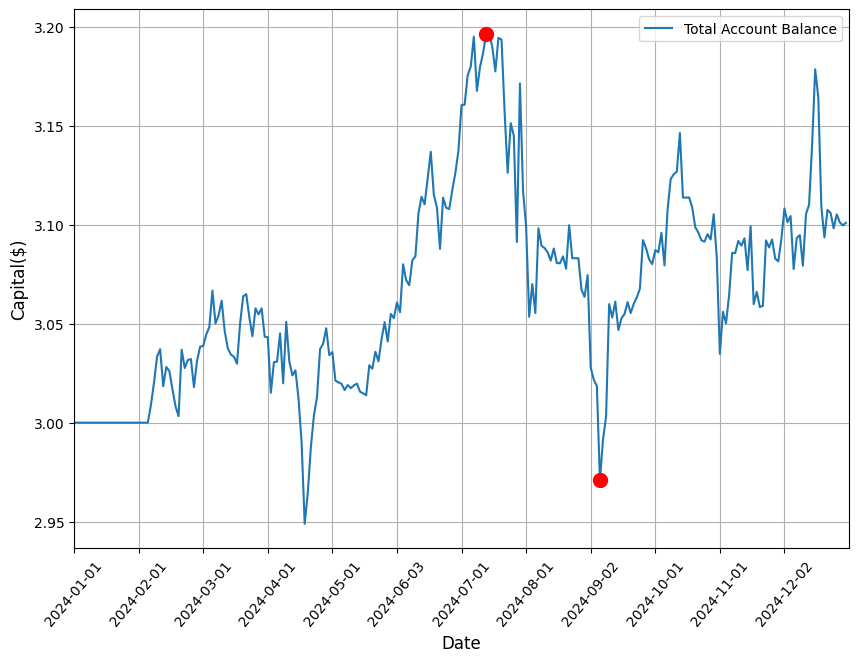

In [57]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  sr_pairs, ticker_segment_dict,
                                                  n_years=1)
results

In [58]:
pairs[1]

('FTC',
 'ONEQ',
 {'t_statistic': -2.9246804168536666,
  'critical_val': {'1%': -3.4346938104971554,
   '5%': -2.863458518103151,
   '10%': -2.567791394384679},
  'p_value': 0.042552356686431765,
  'coint_coef': 1.5736994678996847,
  'zero_cross': 82,
  'half_life': 60,
  'hurst_exponent': 0.4512806721898301,
  'spread': date
  2018-01-02    19.265831
  2018-01-03    19.651264
  2018-01-04    19.800642
  2018-01-05    19.929911
  2018-01-08    20.137873
                  ...    
  2023-12-22    16.780333
  2023-12-26    16.759361
  2023-12-27    16.941341
  2023-12-28    16.765997
  2023-12-29    16.719036
  Length: 1509, dtype: float64,
  'Y_train': date
  2018-01-02     59.363983
  2018-01-03     60.087699
  2018-01-04     60.328938
  2018-01-05     60.792116
  2018-01-08     61.129850
                   ...    
  2023-12-22    109.049714
  2023-12-26    109.528002
  2023-12-27    109.647574
  2023-12-28    109.637610
  2023-12-29    109.169286
  Name: FTC, Length: 1509, dtype: float